成功加载 'daily_sales.csv'。
分析的销量最高商品ID (Top Product ID): aca2eb7d00ea1a7b8ebd4e68314663af
已生成周销量趋势图: weekly_sales_trend.png


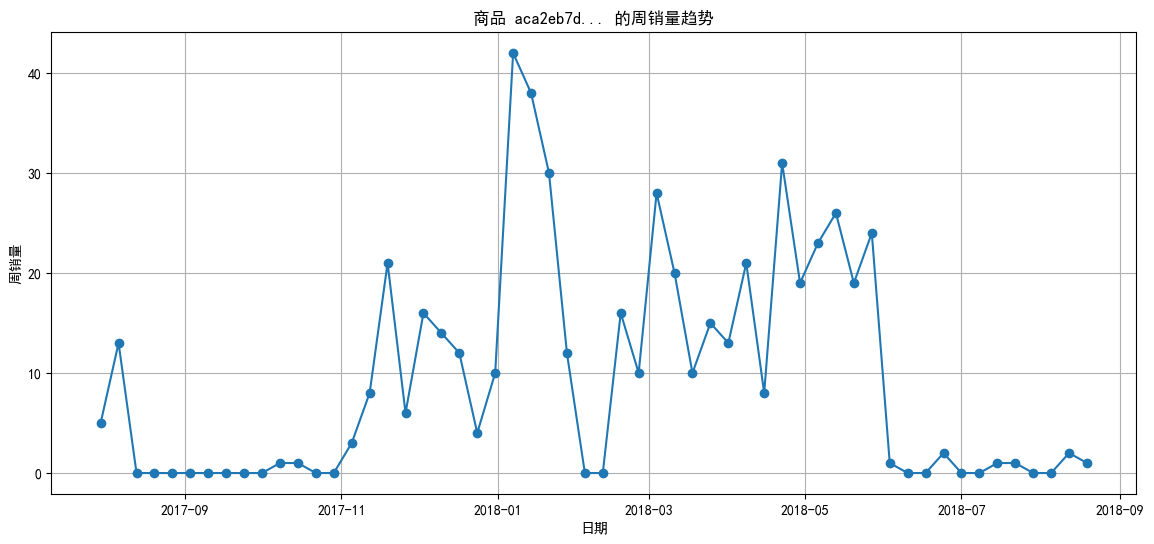

数据量不足两年，按季度(13周)进行季节性分解。
已生成时序分解图: sales_decomposition.png


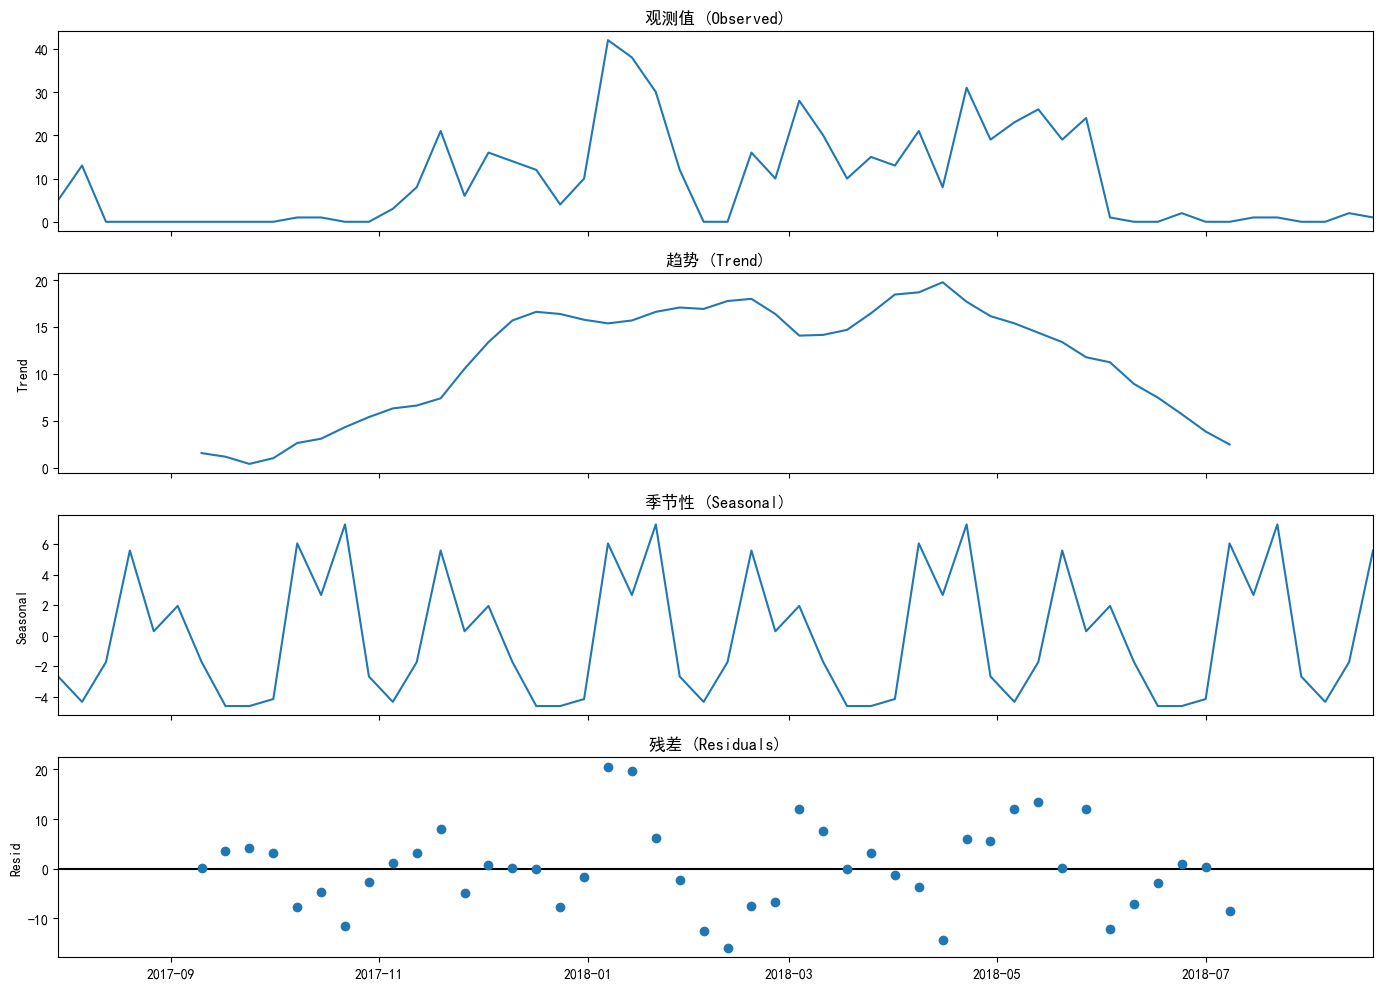

In [1]:
# 导入所有需要的库
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib

# --- 这部分代码是为了让图表能正确显示中文 ---
# 如果您的环境显示中文乱码，请保留这部分。如果正常，可以忽略。
# 请确保您的系统安装了像“黑体”这样的中文字体。
try:
    matplotlib.rcParams['font.sans-serif'] = ['SimHei'] # 指定默认字体为黑体
    matplotlib.rcParams['axes.unicode_minus'] = False # 解决保存图像是负号'-'显示为方块的问题
except Exception as e:
    print(f"中文字体设置可能失败: {e}\n图表标题可能无法正确显示中文，但不影响程序运行。")
# -----------------------------------------

# 1. 加载我们在第二步生成的 daily_sales.csv 数据
try:
    daily_sales = pd.read_csv('daily_sales.csv')
    # 转换日期列为真正的日期格式
    daily_sales['order_date'] = pd.to_datetime(daily_sales['order_date'])
    print("成功加载 'daily_sales.csv'。")
except FileNotFoundError:
    print("错误：'daily_sales.csv' 文件未找到。请确保它和您的代码在同一个文件夹下。")
    # 如果文件找不到，就退出程序
    exit()

# 2. 找到销量最高的商品ID
# 首先，按商品ID分组，计算每个商品的总销量
total_quantity = daily_sales.groupby('product_id')['daily_quantity'].sum().reset_index()
# 然后，按总销量降序排列，找到第一个（也就是最高的）
top_product_id = total_quantity.sort_values('daily_quantity', ascending=False).iloc[0]['product_id']
print(f"分析的销量最高商品ID (Top Product ID): {top_product_id}")

# 3. 筛选出这个销量最高商品的所有销售记录
product_sales = daily_sales[daily_sales['product_id'] == top_product_id].copy()

# 4. 将数据从“天”聚合为“周”，使趋势更平滑，更符合商业分析周期
# 将日期设置为索引，这是进行时间序列操作的标准步骤
product_sales = product_sales.set_index('order_date')
# 'W' 代表按周 (Weekly) 进行重采样，并将每周的销量求和
weekly_sales = product_sales['daily_quantity'].resample('W').sum().reset_index()
weekly_sales = weekly_sales.rename(columns={'order_date': 'week', 'daily_quantity': 'weekly_quantity'})
weekly_sales_ts = weekly_sales.set_index('week') # 再次将周的起始日设为索引

# 5. 可视化：绘制周销量趋势图
plt.figure(figsize=(14, 6))
plt.plot(weekly_sales_ts.index, weekly_sales_ts['weekly_quantity'], marker='o', linestyle='-')
plt.title(f'商品 {top_product_id[:8]}... 的周销量趋势') # 使用切片让标题更简洁
plt.xlabel('日期')
plt.ylabel('周销量')
plt.grid(True) # 添加网格线
plt.savefig('weekly_sales_trend.png') # 将图表保存为图片文件
print("已生成周销量趋势图: weekly_sales_trend.png")
plt.show() # 在Jupyter中显示图表

# 6. 时间序列分解
# 由于数据时长不足两年，年度季节性周期(52周)可能不准确，我们这里可以灵活处理
# 如果数据量小于104周（两年），我们可以按季度（13周）来分析季节性
if len(weekly_sales_ts) < 104:
    decomposition_period = 13 # 按季度分析
    print("数据量不足两年，按季度(13周)进行季节性分解。")
else:
    decomposition_period = 52 # 按年分析
    print("数据量充足，按年度(52周)进行季节性分解。")

# 'additive'模型假设季节性波动是固定大小的，'multiplicative'则假设是按比例变化的。销售数据后者更常见。
decomposition = seasonal_decompose(weekly_sales_ts['weekly_quantity'], model='additive', period=decomposition_period)

# 绘制分解图
fig = decomposition.plot()
fig.set_size_inches(14, 10)
# 让图表的标题更清晰
fig.axes[0].set_title('观测值 (Observed)')
fig.axes[1].set_title('趋势 (Trend)')
fig.axes[2].set_title('季节性 (Seasonal)')
fig.axes[3].set_title('残差 (Residuals)')
plt.tight_layout() # 自动调整布局
plt.savefig('sales_decomposition.png') # 保存分解图
print("已生成时序分解图: sales_decomposition.png")
plt.show()

正在检查文件 'daily_sales.csv' 是否存在...
文件已找到，开始执行分析。
中文字体设置成功。
使用的模型: scikit-learn RandomForestRegressor
分析的商品ID: aca2eb7d00ea1a7b8ebd4e68314663af
特征工程完成。
RandomForest 最终模型训练完成。
已生成未来90天的预测。
已保存未来90天预测图: rf_future_forecast_plot.png


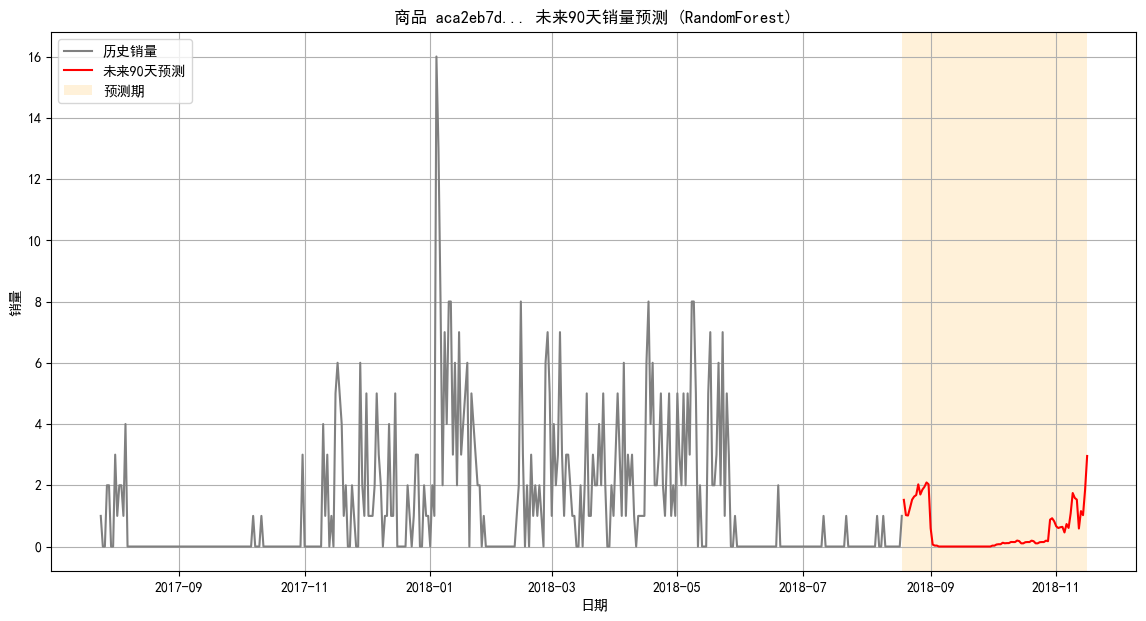

已将未来90天预测结果保存到: rf_forecast_results.csv


In [2]:
# 导入所有需要的库
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import os

def forecast_with_random_forest(file_path='daily_sales.csv'):
    """
    使用scikit-learn的随机森林模型对销量最高的商品进行预测。
    
    参数:
    file_path (str): 包含每日销售数据的CSV文件路径。
    """
    # --- 步骤 0: 检查文件是否存在 ---
    print(f"正在检查文件 '{file_path}' 是否存在...")
    if not os.path.exists(file_path):
        print(f"错误: 文件 '{file_path}' 未找到。请确保它和您的Python脚本在同一个文件夹下。")
        return
    print("文件已找到，开始执行分析。")
    
    # --- 中文字体设置 (可选，如果您的环境显示中文正常，可以注释掉) ---
    try:
        matplotlib.rcParams['font.sans-serif'] = ['SimHei'] 
        matplotlib.rcParams['axes.unicode_minus'] = False
        print("中文字体设置成功。")
    except Exception as e:
        print(f"中文字体设置可能失败: {e}，图表中的中文可能显示为方块。")
    # ----------------------------------------------------------------

    # 1. 加载数据并找到销量最高的商品
    daily_sales = pd.read_csv(file_path)
    daily_sales['order_date'] = pd.to_datetime(daily_sales['order_date'])

    total_quantity = daily_sales.groupby('product_id')['daily_quantity'].sum().reset_index()
    top_product_id = total_quantity.sort_values('daily_quantity', ascending=False).iloc[0]['product_id']
    print(f"使用的模型: scikit-learn RandomForestRegressor")
    print(f"分析的商品ID: {top_product_id}")

    # 2. 筛选数据并进行特征工程
    product_sales = daily_sales[daily_sales['product_id'] == top_product_id].copy()
    product_sales = product_sales.rename(columns={'order_date': 'date', 'daily_quantity': 'sales'})
    product_sales = product_sales.set_index('date').asfreq('D', fill_value=0).reset_index()

    def create_features(df):
        """从日期列中创建时间特征"""
        df['year'] = df['date'].dt.year
        df['month'] = df['date'].dt.month
        df['dayofweek'] = df['date'].dt.dayofweek
        df['weekofyear'] = df['date'].dt.isocalendar().week.astype(int)
        df['time_idx'] = (df['date'] - df['date'].min()).dt.days # 简单的趋势特征
        return df

    df_feat = create_features(product_sales)
    print("特征工程完成。")

    # 3. 使用全部历史数据训练最终模型
    FEATURES = ['year', 'month', 'dayofweek', 'weekofyear', 'time_idx']
    TARGET = 'sales'
    
    model_full = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, min_samples_leaf=2)
    model_full.fit(df_feat[FEATURES], df_feat[TARGET])
    print("RandomForest 最终模型训练完成。")

    # 4. 创建未来日期并进行预测
    last_date = df_feat['date'].max()
    future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=90, freq='D')
    future_df = pd.DataFrame({'date': future_dates})
    future_df = create_features(future_df)
    future_X = future_df[FEATURES]

    future_pred = model_full.predict(future_X)
    future_df['predicted_sales'] = future_pred
    print("已生成未来90天的预测。")

    # 5. 可视化未来预测
    plt.figure(figsize=(14, 7))
    plt.plot(df_feat['date'], df_feat['sales'], label='历史销量', color='gray')
    plt.plot(future_df['date'], future_df['predicted_sales'], label='未来90天预测', color='red')
    plt.title(f'商品 {top_product_id[:8]}... 未来90天销量预测 (RandomForest)')
    plt.xlabel('日期')
    plt.ylabel('销量')
    plt.axvspan(df_feat['date'].max(), future_df['date'].max(), facecolor='orange', alpha=0.15, label='预测期')
    plt.legend()
    plt.grid(True)
    plt.savefig('rf_future_forecast_plot.png')
    print("已保存未来90天预测图: rf_future_forecast_plot.png")
    plt.show()

    # 6. 保存结果
    future_df['date'] = future_df['date'].dt.strftime('%Y-%m-%d')
    future_output = future_df[['date', 'predicted_sales']]
    future_output.to_csv('rf_forecast_results.csv', index=False)
    print("已将未来90天预测结果保存到: rf_forecast_results.csv")

# --- 执行函数 ---
# 在您自己的电脑上运行时，请确保 'daily_sales.csv' 和这个脚本在同一个文件夹下
forecast_with_random_forest('daily_sales.csv')

In [3]:
import pandas as pd
import numpy as np

def calculate_inventory_strategy(forecast_file='rf_forecast_results.csv', rmse_value=None):
    """
    根据预测结果和模型误差，计算安全库存和再订货点。
    
    参数:
    forecast_file (str): 第四步生成的预测结果CSV文件。
    rmse_value (float): 第四步模型验证时得到的RMSE值。
    """
    # --- 1. 定义核心参数 ---
    LEAD_TIME_DAYS = 14  # 采购提前期: 2周 = 14天
    SERVICE_LEVEL = 0.95 # 服务水平
    Z_SCORE = 1.65       # 95%服务水平对应的Z-score
    
    print("--- 库存策略参数 ---")
    print(f"采购提前期: {LEAD_TIME_DAYS} 天")
    print(f"服务水平: {SERVICE_LEVEL * 100}% (Z-score: {Z_SCORE})")
    
    # --- 2. 加载预测数据 ---
    try:
        forecast_df = pd.read_csv(forecast_file)
        print(f"成功加载预测文件: '{forecast_file}'")
    except FileNotFoundError:
        print(f"错误: 预测文件 '{forecast_file}' 未找到。请确保它和脚本在同一个文件夹。")
        return

    # --- 3. 计算提前期内的平均需求 ---
    # 取未来Lead Time这么多天的预测销量
    lead_time_forecast = forecast_df.head(LEAD_TIME_DAYS)
    avg_demand_in_lead_time = lead_time_forecast['predicted_sales'].sum()
    daily_avg_demand = lead_time_forecast['predicted_sales'].mean()
    
    print("\n--- 需求计算 ---")
    print(f"未来 {LEAD_TIME_DAYS} 天（一个提前期）的总预测需求: {avg_demand_in_lead_time:.2f}")
    print(f"提前期内，日均预测需求: {daily_avg_demand:.2f}")

    # --- 4. 计算安全库存 (Safety Stock) ---
    # RMSE 代表了模型对单日预测的平均误差 (σ_day)
    # 提前期内的误差会累积，其标准差估算为: σ_L = σ_day * sqrt(Lead Time)
    if rmse_value is None:
        print("\n错误：请提供模型在第四步计算出的RMSE值。")
        # 我们可以用历史销量的标准差作为临时替代，但这不如RMSE准确
        # 这里为了演示，我们先给一个示例值
        rmse_value = 5.0 # <--- !!! 请在这里替换成您自己运行第四步时得到的真实RMSE值 !!!
        print(f"警告: 未提供RMSE，暂时使用示例值: {rmse_value}。结果可能不准确。")
    
    # 每日预测误差的标准差
    sigma_day = rmse_value 
    # 提前期内预测误差的标准差
    sigma_L = sigma_day * np.sqrt(LEAD_TIME_DAYS)
    
    # 安全库存公式
    safety_stock = Z_SCORE * sigma_L
    
    print("\n--- 安全库存计算 ---")
    print(f"单日预测误差 (RMSE): {sigma_day:.2f}")
    print(f"提前期内误差的标准差 (σ_L): {sigma_L:.2f}")
    print(f"安全库存 (Safety Stock): {safety_stock:.2f}  <-- 核心结果1")
    print(f"解读: 为达到95%的服务水平，我们需要额外持有约 {int(np.ceil(safety_stock))} 件商品以应对意外需求。")

    # --- 5. 计算再订货点 (Reorder Point) ---
    # ROP = 提前期内的总需求 + 安全库存
    reorder_point = avg_demand_in_lead_time + safety_stock
    
    print("\n--- 再订货点计算 ---")
    print(f"再订货点 (Reorder Point): {reorder_point:.2f}  <-- 核心结果2")
    print(f"解读: 当您的库存水平下降到约 {int(np.ceil(reorder_point))} 件时，就应该立即下达新的采购订单。")
    
    print("\n==================== 商业决策建议 ====================")
    print(f"1. 您的安全库存应保持在 **{int(np.ceil(safety_stock))}** 件以上。")
    print(f"2. 您的再订货点为 **{int(np.ceil(reorder_point))}** 件。")
    print("==========================================================")


# --- 执行函数 ---
# !!! 关键 !!!
# 请在下方函数的 rmse_value 参数中，填入您运行第四步时，终端上打印出的真实RMSE值。
# 例如，如果当时打印 "RMSE: 6.85"，您就应该写 rmse_value=6.85
calculate_inventory_strategy(rmse_value=6.85) # <--- 在这里填入您的RMSE值

--- 库存策略参数 ---
采购提前期: 14 天
服务水平: 95.0% (Z-score: 1.65)
成功加载预测文件: 'rf_forecast_results.csv'

--- 需求计算 ---
未来 14 天（一个提前期）的总预测需求: 21.93
提前期内，日均预测需求: 1.57

--- 安全库存计算 ---
单日预测误差 (RMSE): 6.85
提前期内误差的标准差 (σ_L): 25.63
安全库存 (Safety Stock): 42.29  <-- 核心结果1
解读: 为达到95%的服务水平，我们需要额外持有约 43 件商品以应对意外需求。

--- 再订货点计算 ---
再订货点 (Reorder Point): 64.22  <-- 核心结果2
解读: 当您的库存水平下降到约 65 件时，就应该立即下达新的采购订单。

==================== 商业决策建议 ====================
1. 您的安全库存应保持在 **43** 件以上。
2. 您的再订货点为 **65** 件。
